# **Parte I**

In [8]:
from simplex import Simplex
import l1_svm
from pandas import DataFrame
import matplotlib.pyplot as plt
import numpy as np

Todo el código de este ejercicio está implementado en dos módulos: `simplex.py` y `l1_svm.py`. En este notebook se muestran ejemplos de cómo usar las funciones implementadas en dichos módulos, y se detalla la lógica utilizada en algunas de las funciones más importantes.

## Módulo `Simplex`

Este módulo implementa una clase llamada Simplex que recibe una matriz de simplex primal, (maximización con restricciones de holgura), y a partir de ella podemos acceder a diferentes métodos para resolver los diferentes tipos de algoritmos simplex.

_La matriz de simplex primal tiene la siguiente forma:_


$$
\begin{aligned}
\arg\max_{\mathbf{x}}\quad & z = \sum_i c_i x_i \\
\text{sujeto a}\quad & \sum_i a_{ji} x_i \le b_j,\quad \forall j\\
& x_i \ge 0,\quad \forall i
\end{aligned}
\quad\Rightarrow\quad
\begin{cases}
z - \mathbf{c}^\top \mathbf{x} = 0,\\[0.3em]
\mathbf{A}\mathbf{x} = \mathbf{b},\\[0.3em]
\mathbf{x} \ge 0
\end{cases}
\quad\Rightarrow\quad
\left[
\begin{array}{ccc}
1 & -\mathbf{c}^\top & 0 \\[0.3em]
0 & \mathbf{A} & \mathbf{b}
\end{array}
\right]
$$


In [9]:
# Ejemplo

ejemplo = [
    [1, -3, -5, 0, 0, 0],   # función objetivo: Z = 3x1 + 5x2
    [0, 2, 1, 1, 0, 12],    # restricción 1
    [0, -1, 1, 0, 1, 3]     # restricción 2
]

ejemplo = np.array(ejemplo, dtype=float)

In [10]:
s1 = Simplex(ejemplo)

In [11]:
print(s1.original_matrix)

[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]


###  `iterate(self, type, return_extra_info=False):`

A continuación, un ejemplo de cómo se puede usar para realizar iteraciones de simplex tanto primal como dual:

In [12]:
s1 = Simplex(ejemplo)
print("Antes de la iteración:")
print(s1.original_matrix)
base, arguments, point, objective_value = s1.iterate(version='primal', return_extra_info=True)
print("\n Después de la iteración:")
print(s1.current_matrix.round(2))

print("-"*30)
print("Información extra:")
print("Base:", base)
print("Argumentos:", arguments)
print("Punto:", point)
print("Valor objetivo:", objective_value)

Antes de la iteración:
[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]

 Después de la iteración:
[[ 1. -8.  0.  0.  5. 15.]
 [ 0. -1.  1.  0.  1.  3.]
 [ 0.  3.  0.  1. -1.  9.]]
------------------------------
Información extra:
Base: [1, 2]
Argumentos: [3. 9.]
Punto: [0, 3.0]
Valor objetivo: 15.0


Observamos que ha cambiado la base de: $B_0 = \{s_1, s_2\} \Rightarrow B_1 = \{x_2, s_1\}$ y ha realizado la iteración correspondiente de simplex primal, de igual manera se puede utilizar para simplex dual.

###  `solver(self, version, printear_intermedios = True, return_history = False):`

Itera según la versión del simplex, hasta que se cumpla la condición de parada correspondiente.

`printer_intermedios`: Hace un resumen de lo que pasa en cada iteración. <br>
`return_history`: Devuelve un historial con lo que ocurrió en cada iteración.

In [13]:
s1 = Simplex(ejemplo)
history = solution = s1.solver(version='primal', printear_intermedios=True, return_history=True)

------------------------------------------------------------

- Iteracion 0
- Base actual: ['s1', 's2']
- Argumentos actuales: [12.  3.]
- Punto actual: [0. 0.]
- Valor objetivo actual: 0.0

 - Matriz actual:
[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]

 - Matriz original:
[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 1
- Variable de entrada: x2
- Variable de salida: s2
- Base actual: ['x2', 's1']
- Argumentos actuales: [3. 9.]
- Punto actual: [0. 3.]
- Valor objetivo actual: 15.0

 - Matriz actual:
[[ 1. -8.  0.  0.  5. 15.]
 [ 0. -1.  1.  0.  1.  3.]
 [ 0.  3.  0.  1. -1.  9.]]

 - Matriz original:
[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]
------------------------------------------------------------
----------------------------------------

In [14]:
history

[{'iteration': 0,
  'base': array([2, 3]),
  'str_base': ['s1', 's2'],
  'arguments': array([12.,  3.]),
  'point': array([0., 0.]),
  'objective_value': np.float64(0.0)},
 {'iteration': 1,
  'base': array([1, 2]),
  'str_base': ['x2', 's1'],
  'arguments': array([3., 9.]),
  'point': array([0., 3.]),
  'objective_value': np.float64(15.0),
  'v_in': 1,
  'v_out': 3},
 {'iteration': 2,
  'base': array([0, 1]),
  'str_base': ['x1', 'x2'],
  'arguments': array([3., 6.]),
  'point': array([3., 6.]),
  'objective_value': np.float64(39.0),
  'v_in': 0,
  'v_out': 2},
 {'iteration': 3,
  'base': array([0, 1]),
  'str_base': ['x1', 'x2'],
  'arguments': array([3., 6.]),
  'point': array([3., 6.]),
  'objective_value': np.float64(39.0)}]

Además, este histórico se puede plotear usando la función `plot_sol_history(self, size=n)`, pero solo para problemas con dos variables.

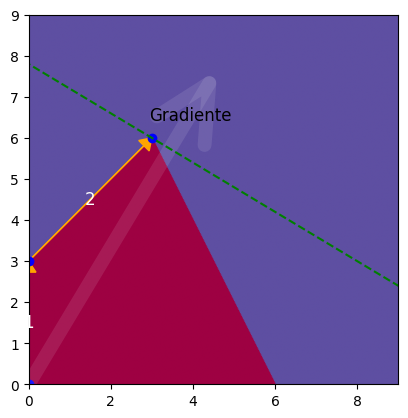

In [15]:
s1.plot_sol_history(size=9)

###  `transform_to_dual()`

Además, hemos implementado un método que nos permite transformar un problema de simplex primal en su versión dual, usamos como ejemplo el problema del examen.

$$
\begin{array}{rcl}
\begin{aligned}
\argmax \quad & z = c^T x \\
\text{s.a.} \quad & A x \le b \\
& x \ge 0
\end{aligned}
& \Longrightarrow &
\begin{aligned}
\argmin \quad & z = b^T y \\
\text{s.a.} \quad & A^T y \ge c \\
& y \ge 0
\end{aligned}
\end{array}
$$

In [16]:
ejemplo_examen = [
    [1, -1, 0, 0, 0, 0],
    [0, 2, 1, 1, 0, 10],
    [0, -1, -1, 0, 1, -3]
]

ejemplo_examen = np.array(ejemplo_examen, dtype=float)

In [17]:
s1 = Simplex(ejemplo_examen)
print("Matriz original:")
print(s1.original_matrix)

s2 = Simplex(ejemplo_examen)
s2.transform_to_dual()
print("\n Matriz dual:")
print(s2.current_matrix)

Matriz original:
[[ 1. -1.  0.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 10.]
 [ 0. -1. -1.  0.  1. -3.]]

 Matriz dual:
[[  1. -10.   3.   0.   0.   0.]
 [  0.  -2.   1.   1.   0.  -1.]
 [  0.  -1.   1.   0.   1.   0.]]


Luego, ambos problemas pueden ser resueltos con el mismo objeto `Simplex`, usando el metodo `solver` y especificando la versión que queremos usar.

--------------------ITERANDO CON EL DUAL--------------------
------------------------------------------------------------

- Iteracion 0
- Base actual: ['s1', 's2']
- Argumentos actuales: [10. -3.]
- Punto actual: [0. 0.]
- Valor objetivo actual: -0.0

 - Matriz actual:
[[ 1.  1. -0. -0. -0. -0.]
 [ 0.  2.  1.  1.  0. 10.]
 [ 0. -1. -1.  0.  1. -3.]]

 - Matriz original:
[[ 1.  1. -0. -0. -0. -0.]
 [ 0.  2.  1.  1.  0. 10.]
 [ 0. -1. -1.  0.  1. -3.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 1
- Variable de entrada: x2
- Variable de salida: s2
- Base actual: ['x2', 's1']
- Argumentos actuales: [3. 7.]
- Punto actual: [0. 3.]
- Valor objetivo actual: 0.0

 - Matriz actual:
[[ 1.  1.  0.  0.  0.  0.]
 [ 0.  1.  1.  0. -1.  3.]
 [ 0.  1.  0.  1.  1.  7.]]

 - Matriz original:
[[ 1.  1. -0. -0. -0. -0.]
 [ 0.  2.  1.  1.  0. 10.]
 [ 0. -1. -1.  0.  1. -3.]]
----------------------------------------

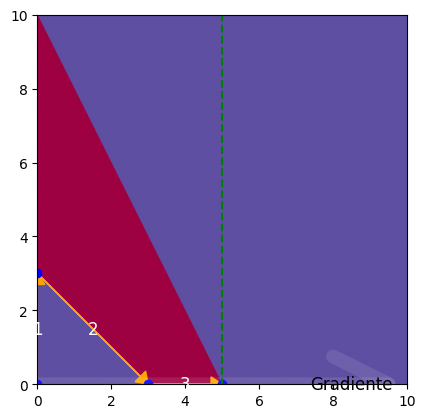

In [18]:
s1.combined_solver()
s1.plot_sol_history()

Y plotear el historial del dual.

------------------------------------------------------------

- Iteracion 0
- Base actual: ['s1', 's2']
- Argumentos actuales: [-1.  0.]
- Punto actual: [0. 0.]
- Valor objetivo actual: 0.0

 - Matriz actual:
[[  1. -10.   3.   0.   0.   0.]
 [  0.  -2.   1.   1.   0.  -1.]
 [  0.  -1.   1.   0.   1.   0.]]

 - Matriz original:
[[  1. -10.   3.   0.   0.   0.]
 [  0.  -2.   1.   1.   0.  -1.]
 [  0.  -1.   1.   0.   1.   0.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 1
- Base actual: ['x1', 's2']
- Argumentos actuales: [0.5 0.5]
- Punto actual: [0.5 0. ]
- Valor objetivo actual: 5.0

 - Matriz actual:
[[ 1.   0.  -2.  -5.   0.   5. ]
 [ 0.   1.  -0.5 -0.5  0.   0.5]
 [ 0.   0.   0.5 -0.5  1.   0.5]]

 - Matriz original:
[[  1. -10.   3.   0.   0.   0.]
 [  0.  -2.   1.   1.   0.  -1.]
 [  0.  -1.   1.   0.   1.   0.]]
------------------------------------------------------------


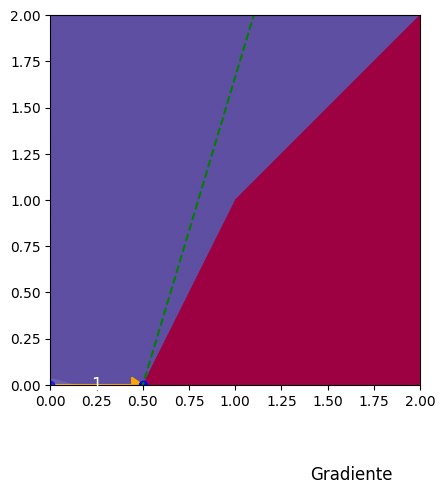

In [19]:
s2.solver(version='dual', printear_intermedios=True, return_history=True)
s2.plot_sol_history(size=2)

Además, utilizando los Teoremas de holgura complementaria y de dualidad fuerte, podemos recuperar la solución primal a partir de la solución dual, usando el método <br>
 ### `get_primal_solution_from_dual_solution(printear = True)`.

In [20]:
primal_sol = s2.get_primal_solution_from_dual_solution(printear = True)

------------------------------------------------------------
Solución del problema primal obtenida desde la solución del dual:
Base primal: ['s2', 'x1']
Punto primal: [5. 0.]
Valor objetivo: 5.0
------------------------------------------------------------


In [21]:
print("Solución primal recuperado:", primal_sol)
print("Solucion primal directo:", s1.point)

print("Valor objetivo primal recuperado:", s2.objective_value)
print("Valor objetivo primal directo:", s1.objective_value)

Solución primal recuperado: [5.0, 0]
Solucion primal directo: [5.0, 0]
Valor objetivo primal recuperado: 5.0
Valor objetivo primal directo: 5.0


Ambos resultados coinciden, ahora podemos elegir cual de los métodos usar para ahorrar iteraciones o disminuir el numero de restricciones para evitar hacer inversas de matrices muy grandes.
En el ejemplo del examen, se podía resolver pasando al problema dual, en una sola iteración.

### `combined_solver()`

Este método implementa el algoritmo del simplex combinado, y lo usamos para un problema donde el origen de coordenadas sea no factible para simplex primal.

In [22]:
ejemplo_dual = [
    [1, -3, -2, 0, 0, 0, 0, 0, 0],
    [0, -1, -1, 1, 0, 0, 0, 0, -2],
    [0, 1, 2, 0, 1, 0, 0, 0, 8],
    [0, 2, 1, 0, 0, 1, 0, 0, 8],
    [0, 1, -1, 0, 0, 0, 1, 0, 1],
    [0, -1, 1, 0, 0, 0, 0, 1, 1]
]

ejemplo_dual = np.array(ejemplo_dual, dtype=float)

In [23]:
s1 = Simplex(ejemplo_dual)
s1.combined_solver()

--------------------ITERANDO CON EL DUAL--------------------
------------------------------------------------------------

- Iteracion 0
- Base actual: ['s1', 's2', 's3', 's4', 's5']
- Argumentos actuales: [-2.  8.  8.  1.  1.]
- Punto actual: [0. 0.]
- Valor objetivo actual: -0.0

 - Matriz actual:
[[ 1.  3.  2. -0. -0. -0. -0. -0. -0.]
 [ 0. -1. -1.  1.  0.  0.  0.  0. -2.]
 [ 0.  1.  2.  0.  1.  0.  0.  0.  8.]
 [ 0.  2.  1.  0.  0.  1.  0.  0.  8.]
 [ 0.  1. -1.  0.  0.  0.  1.  0.  1.]
 [ 0. -1.  1.  0.  0.  0.  0.  1.  1.]]

 - Matriz original:
[[ 1.  3.  2. -0. -0. -0. -0. -0. -0.]
 [ 0. -1. -1.  1.  0.  0.  0.  0. -2.]
 [ 0.  1.  2.  0.  1.  0.  0.  0.  8.]
 [ 0.  2.  1.  0.  0.  1.  0.  0.  8.]
 [ 0.  1. -1.  0.  0.  0.  1.  0.  1.]
 [ 0. -1.  1.  0.  0.  0.  0.  1.  1.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 1
- Base actual: ['x2', 's2', 's3', 's4', 's5']
- Argumentos actuales: [ 

c:\Users\Usuario\OneDrive - Universidad Politécnica de Madrid\Tercero\Primer Cuatri\IO - Investigación Operativa\io-practica1\simplex.py:101: RuntimeWarning: divide by zero encountered in divide
  cocients = self.b_submatrix / self.A_submatrix[:, B_in]


Ploteamos el historial que se ha generado:

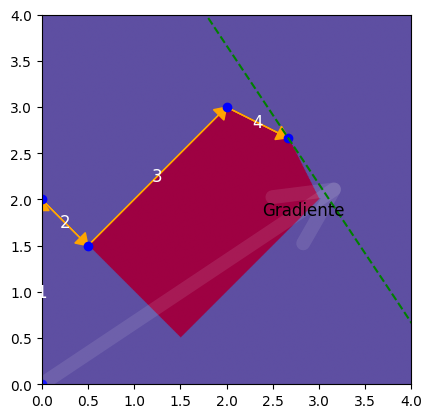

In [24]:
s1.plot_sol_history(size=4)

## Módulo `l1_svm`

Este módulo hace uso de la clase `Simplex` para implementar un clasificador SVM eligiendo la norma L1 en lugar de la norma L2 habitual.

### `generar_datos_svm(n_samples=N, random_state=SEED)`

Genera un conjunto de datos aleatorios para entrenar un clasificador SVM, se generan con centros separados, pero no tienen por qué ser linealmente separables.

In [25]:
X, y = l1_svm.generar_datos_svm(100, random_state=42)

In [26]:
DataFrame(np.concatenate((X, y.reshape(-1, 1)), axis=1), columns=['X1', 'X2', 'Y'])

,X1,X2,Y
0,-3.707133,8.550139,-1.0
1,7.347507,4.607675,1.0
2,-3.870154,9.291593,-1.0
3,6.695029,6.715152,1.0
4,5.208529,5.241027,1.0
...,...,...,...
95,0.068301,11.342486,-1.0
96,-0.220692,9.836164,-1.0
97,2.522895,-1.813948,1.0
98,-3.058377,9.907068,-1.0


### `generate_svm_matrix(X, y, C)`

Genera la matriz de simplex primal correspondiente al problema L1-SVM, a partir de los datos de entrada `X` e `y`, y el parámetro `C`.

In [27]:
C = 0.1

DataFrame(l1_svm.generate_svm_matrix(X, y, C))

,0,1,2,3,4,5,6,7,8,9,...,198,199,200,201,202,203,204,205,206,207
0,1.0,0.500000,0.500000,0.500000,0.500000,0.0,0.0,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.0
1,0.0,-3.707133,8.550139,3.707133,-8.550139,1.0,-1.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
2,0.0,-7.347507,-4.607675,7.347507,4.607675,-1.0,1.0,0.0,-1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
3,0.0,-3.870154,9.291593,3.870154,-9.291593,1.0,-1.0,0.0,0.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
4,0.0,-6.695029,-6.715152,6.695029,6.715152,-1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.0,0.068301,11.342486,-0.068301,-11.342486,1.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0
97,0.0,-0.220692,9.836164,0.220692,-9.836164,1.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.0
98,0.0,-2.522895,1.813948,2.522895,-1.813948,-1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0
99,0.0,-3.058377,9.907068,3.058377,-9.907068,1.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.0


### `solve_simplex_svm(X, y, C, print_sol = True, plot=True, print_acc=True):`

--------------------ITERANDO CON EL DUAL--------------------
------------------------------------------------------------

- Iteracion 0
- Base actual: ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27', 's28', 's29', 's30', 's31', 's32', 's33', 's34', 's35', 's36', 's37', 's38', 's39', 's40', 's41', 's42', 's43', 's44', 's45', 's46', 's47', 's48', 's49', 's50', 's51', 's52', 's53', 's54', 's55', 's56', 's57', 's58', 's59', 's60', 's61', 's62', 's63', 's64', 's65', 's66', 's67', 's68', 's69', 's70', 's71', 's72', 's73', 's74', 's75', 's76', 's77', 's78', 's79', 's80', 's81', 's82', 's83', 's84', 's85', 's86', 's87', 's88', 's89', 's90', 's91', 's92', 's93', 's94', 's95', 's96', 's97', 's98', 's99', 's100']
- Argumentos actuales: [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1

c:\Users\Usuario\OneDrive - Universidad Politécnica de Madrid\Tercero\Primer Cuatri\IO - Investigación Operativa\io-practica1\simplex.py:134: RuntimeWarning: overflow encountered in divide
  cocients = np.abs(numerators[mask] / denominators[mask])


------------------------------------------------------------

- Iteracion 99
- Base actual: ['x1', 'x4', 'x5', 'x7', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x21', 'x22', 'x23', 'x24', 'x26', 'x28', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x49', 'x50', 'x51', 'x52', 'x54', 'x55', 'x56', 'x57', 'x59', 'x60', 'x61', 'x65', 'x66', 'x67', 'x68', 'x70', 'x72', 'x75', 'x78', 'x81', 'x82', 'x85', 'x86', 'x89', 'x90', 'x91', 'x92', 'x99', 'x101', 'x102', 'x103', 'x106', 's2', 's14', 's19', 's21', 's23', 's24', 's32', 's33', 's42', 's47', 's52', 's56', 's58', 's63', 's65', 's67', 's68', 's71', 's73', 's74', 's77', 's78', 's81', 's82', 's87', 's88', 's89', 's90', 's91', 's92', 's94', 's99']
- Argumentos actuales: [ 0.15872311  0.09357178  0.42982395  0.04136452 -0.05388988  0.13586897
  0.2338744  -0.02831401  0.10206254  0.64970726  0.37484117 -0.07260068
  0.54815976  0.20029102 -0.12513839  0.

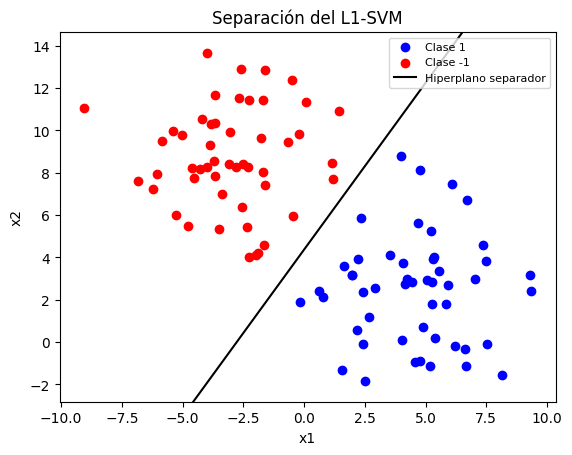

Accuracy = 1.0


In [28]:
l1_svm.solve_simplex_svm(X, y, C, print_sol = True, plot=True, print_acc=True)

Por último, un ejemplo con datos generados aleatoriamente cada vez que se ejecuta la celda.

--------------------ITERANDO CON EL DUAL--------------------
------------------------------------------------------------

- Iteracion 0
- Base actual: ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27', 's28', 's29', 's30', 's31', 's32', 's33', 's34', 's35', 's36', 's37', 's38', 's39', 's40', 's41', 's42', 's43', 's44', 's45', 's46', 's47', 's48', 's49', 's50', 's51', 's52', 's53', 's54', 's55', 's56', 's57', 's58', 's59', 's60', 's61', 's62', 's63', 's64', 's65', 's66', 's67', 's68', 's69', 's70', 's71', 's72', 's73', 's74', 's75', 's76', 's77', 's78', 's79', 's80', 's81', 's82', 's83', 's84', 's85', 's86', 's87', 's88', 's89', 's90', 's91', 's92', 's93', 's94', 's95', 's96', 's97', 's98', 's99', 's100']
- Argumentos actuales: [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1

------------------------------------------------------------

- Iteracion 2
- Base actual: ['x5', 'x7', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27', 's28', 's29', 's30', 's31', 's32', 's33', 's34', 's35', 's36', 's37', 's38', 's39', 's40', 's41', 's42', 's43', 's44', 's45', 's46', 's47', 's48', 's49', 's50', 's51', 's52', 's53', 's54', 's55', 's56', 's57', 's58', 's59', 's60', 's61', 's62', 's63', 's64', 's65', 's66', 's67', 's68', 's69', 's70', 's71', 's72', 's73', 's74', 's75', 's76', 's77', 's78', 's79', 's80', 's81', 's82', 's83', 's84', 's85', 's86', 's87', 's88', 's89', 's90', 's91', 's92', 's93', 's94', 's95', 's96', 's97', 's98', 's99', 's100']
- Argumentos actuales: [-1.  2.  0.  0. -2.  0. -2.  0.  0. -2.  0.  0. -2. -2.  0.  0.  0. -2.
  0. -2.  0. -2.  0. -2.  0. -2.  0.  0. -2.  0. -2.  0. -2. -2. -2. -2.
  0.  0. -2. -2.  0. -2. -2.  0.  0.  0. -2. -2

c:\Users\Usuario\OneDrive - Universidad Politécnica de Madrid\Tercero\Primer Cuatri\IO - Investigación Operativa\io-practica1\simplex.py:101: RuntimeWarning: divide by zero encountered in divide
  cocients = self.b_submatrix / self.A_submatrix[:, B_in]
c:\Users\Usuario\OneDrive - Universidad Politécnica de Madrid\Tercero\Primer Cuatri\IO - Investigación Operativa\io-practica1\simplex.py:101: RuntimeWarning: overflow encountered in divide
  cocients = self.b_submatrix / self.A_submatrix[:, B_in]


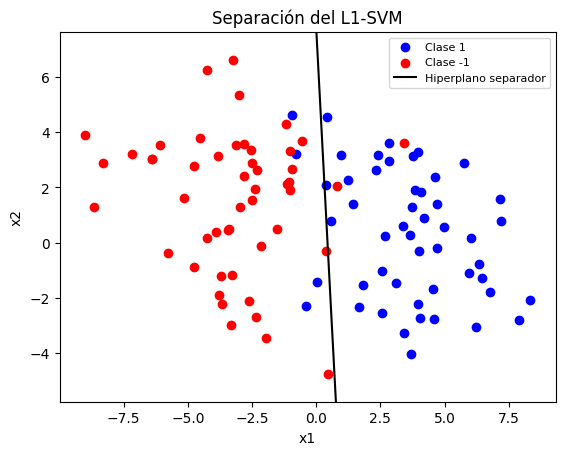

Accuracy = 0.94


In [29]:
from random import randint

SAMPLES = 100

X, y = l1_svm.generar_datos_svm(n_samples=SAMPLES, random_state=randint(1, 1000))
l1_svm.solve_simplex_svm(X, y, C=0.1, print_sol=True, plot=True, print_acc=True)


# **Parte 2**

## Apartado I
Lo hemos hecho en el módulo ``NN.py``, el modelo es ``modelo.pth``.

Usamos la libreria ``pytorch`` .

## Apartado II

Lo hemos hecho en el módulo ``SVM.py``, el modelo es ``SVC.pkl``.

## Apartado III
Lo hemos hecho en el módulo ``FGSM.py``.

## Apartado IV y V

### Cargamos el Dataset de MNIST

In [ ]:
import torch
import joblib
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score
from FGSM import get_adversarial_images
from torch.utils.data import DataLoader, TensorDataset
from NN import NN

# Transformación de imagen a tensor
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor = train_dataset.data.float() / 255, train_dataset.targets,\
																test_dataset.data.float() / 255, test_dataset.targets

X_train, y_train = train_dataset.data.numpy(), train_dataset.targets.numpy()
X_test, y_test = test_dataset.data.numpy(), test_dataset.targets.numpy()

X_train, X_test = X_train.reshape(len(X_train), -1) / 255, X_test.reshape(len(X_test), -1) / 255

### Cargamos los modelos que hemos entrenado y guardado en los archivos python.

In [ ]:
red = NN(28*28)
red.load_state_dict(torch.load('modelo.pth', map_location= torch.device('cpu'), weights_only= True))
red.eval()

svc = joblib.load('SVC.pkl')

### Comprobamos el accuracy de estos modelos.

In [ ]:

print(f'Accuracy red: {red.accuracy(X_train_tensor, y_train_tensor, device= "cpu")}')
print(f'Accuracy SVC: {accuracy_score(y_test, svc.predict(X_test))}')

c:\Users\Usuario\Desktop\Programacion\Python\pyver\py3127\Lib\site-packages\torch\utils\data\dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Accuracy red: 0.9958666666666667
Accuracy SVC: 0.9833


### Generamos las imagenes adversarias y tratamos de predecirlas con la red y con la SVC.

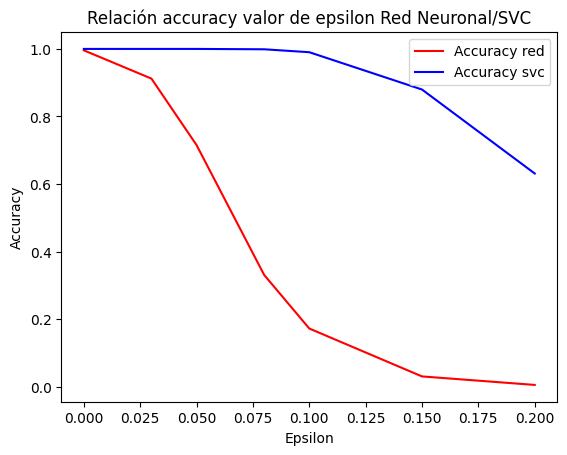

In [ ]:
epsilons = [0.0, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2]
accuracies_red = []
accuracies_svc = []
imagenes_adversarias = {}

test_dataset_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size= 2048)

for epsilon in epsilons:
        
        modified_images, labels = get_adversarial_images(red, test_dataset_loader, epsilon= epsilon, device= 'cpu')
        imagenes_adversarias[epsilon] = modified_images

        # Primero lo hacemos para la red neuronal
        with torch.no_grad():
            outputs = red(modified_images)
            y_pred = torch.argmax(outputs, dim= 1)
        # Calculamos el accuracy.
        accuracies_red.append((y_pred == labels).float().mean().item())
        
		# Ahora para la svc
        y_pred = svc.predict(modified_images.detach().numpy().reshape(len(modified_images), 28*28))
        accuracies_svc.append((y_pred == labels.numpy()).mean())
        
plt.title('Relación accuracy valor de epsilon Red Neuronal/SVC')
plt.plot(epsilons, accuracies_red, color= 'red', label= 'Accuracy red')
plt.plot(epsilons, accuracies_svc, color= 'blue', label= 'Accuracy svc')
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Vamos a visualizar 5 imágenes adversarias aleatorias y ver las predicciones con los diferentes epsilons para ver si realmente están cambiando.

In [ ]:
indices = torch.randperm(len(test_dataset))[:5]

Imágenes adversarias con epsilon= 0.0
Red: [7, 9, 0, 6, 2]
SVC: [7, 9, 0, 6, 2]


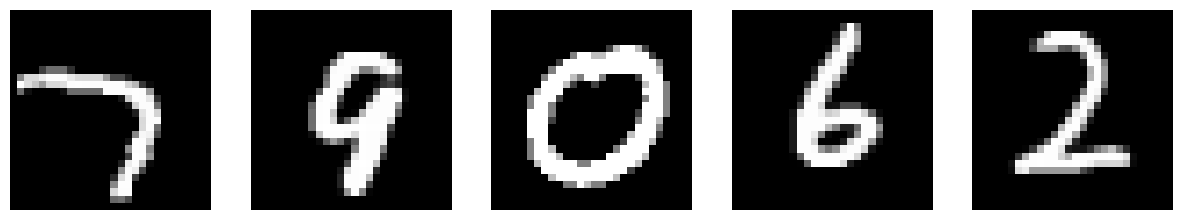

Imágenes adversarias con epsilon= 0.03
Red: [7, 9, 0, 6, 2]
SVC: [7, 9, 0, 6, 2]


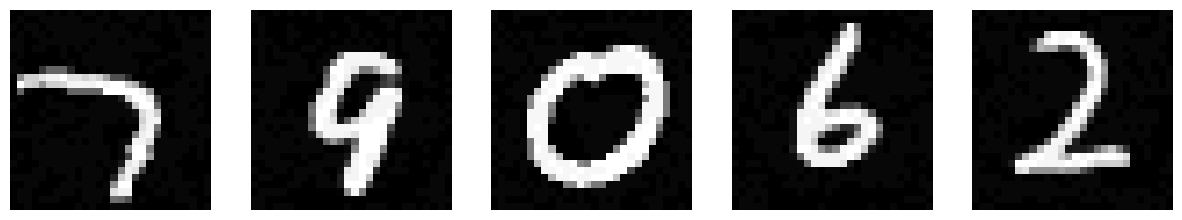

Imágenes adversarias con epsilon= 0.05
Red: [7, 9, 0, 6, 2]
SVC: [7, 9, 0, 6, 2]


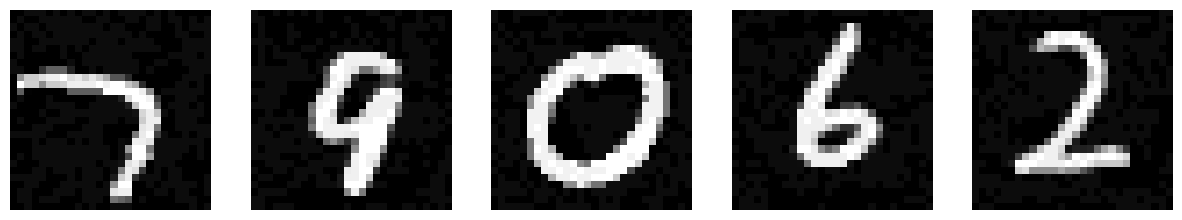

Imágenes adversarias con epsilon= 0.08
Red: [3, 4, 0, 6, 3]
SVC: [7, 9, 0, 6, 2]


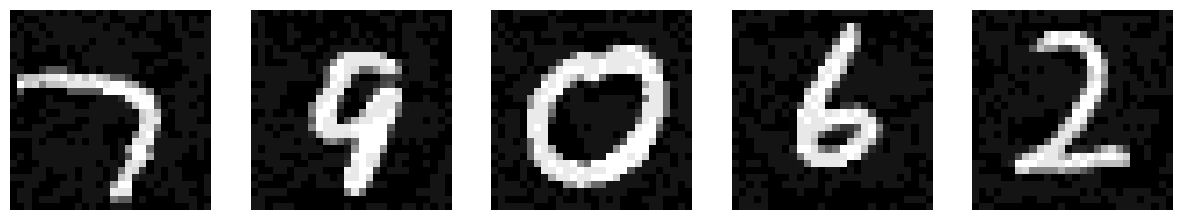

Imágenes adversarias con epsilon= 0.1
Red: [3, 4, 0, 6, 3]
SVC: [7, 9, 0, 6, 2]


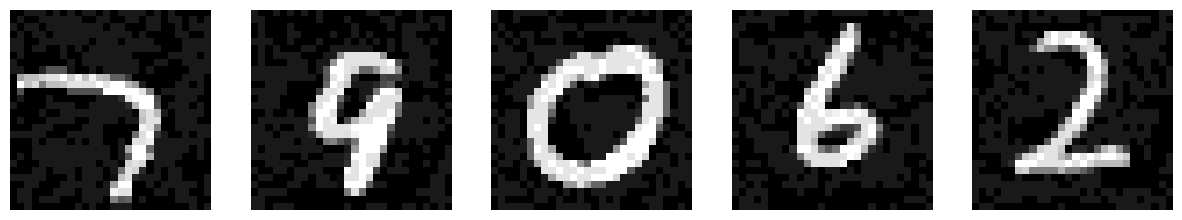

Imágenes adversarias con epsilon= 0.15
Red: [3, 4, 0, 4, 3]
SVC: [7, 9, 0, 6, 2]


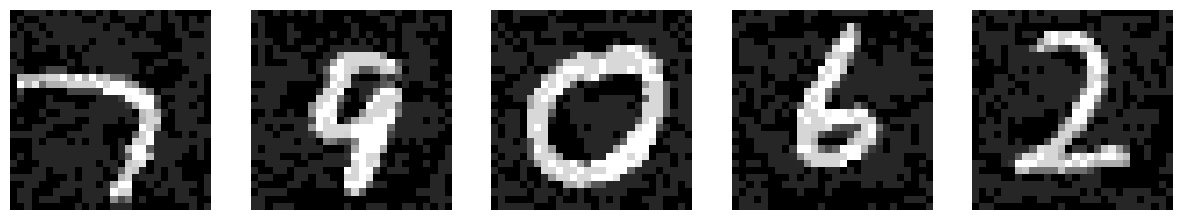

Imágenes adversarias con epsilon= 0.2
Red: [3, 4, 0, 8, 3]
SVC: [7, 4, 0, 6, 2]


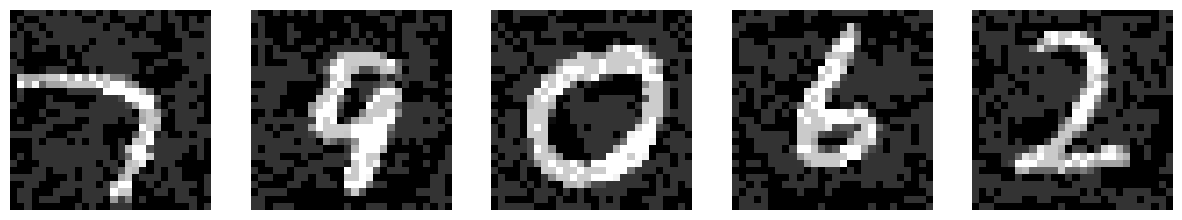

In [ ]:
for epsilon in epsilons:
	print(f'Imágenes adversarias con epsilon= {epsilon}')
	imgs = imagenes_adversarias[epsilon][indices]

	preds_red = []
	preds_svc = []

	plt.figure(figsize=(15, 3))
	for i in range(len(indices)):
		img = imgs[i]
		with torch.no_grad():
			pred_red = torch.argmax(red(img.unsqueeze(0)), dim=1).item()
		pred_svc = int(svc.predict(img.detach().numpy().reshape(1, -1))[0])

		preds_red.append(pred_red)
		preds_svc.append(pred_svc)

		plt.subplot(1, 5, i + 1)
		plt.imshow((img.detach().numpy().squeeze() * 255).astype('uint8'), cmap='gray')
		plt.axis('off')

	print('Red:', preds_red)
	print('SVC:', preds_svc)

	plt.show()


## Apartado VI

Generamos imágenes adversarias para entrenar a los modelos con ellas. Vamos a elegir epsilon 0.2 ya que como se puede ver los números siguen siendo reconocibles y además es cuando la red empieza a ir a accuracy muy próximo a 0.

In [ ]:
# Generamos las imágenes adversarias para entrenamiento y test
train_dataset_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size= 2048)
modified_images_train, labels_train = get_adversarial_images(red, train_dataset_loader, epsilon= 0.2, device= 'cpu')
test_dataset_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size= 2048)
modified_images_test, labels_test = get_adversarial_images(red, test_dataset_loader, epsilon= 0.2, device= 'cpu')

# Equivalente a poner require_grad False
modified_images_train = modified_images_train.detach()
modified_images_test = modified_images_test.detach()

X_adversarial_train = torch.cat([X_train_tensor, modified_images_train], dim= 0)
y_adversarial_train = torch.cat([y_train_tensor, labels_train], dim= 0)
X_adversarial_test = torch.cat([X_test_tensor, modified_images_test], dim= 0)
y_adversarial_test = torch.cat([y_test_tensor, labels_test], dim= 0)

  0%|          | 0/10 [00:00<?, ?it/s]c:\Users\Usuario\Desktop\Programacion\Python\pyver\py3127\Lib\site-packages\torch\utils\data\dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
 10%|█         | 1/10 [00:15<02:19, 15.52s/it]

Epoch 1/10 | Train Loss: 0.3560 | Val Loss: 0.0008 | Accuracy: 97.91%


 20%|██        | 2/10 [00:28<01:54, 14.30s/it]

Epoch 2/10 | Train Loss: 0.0985 | Val Loss: 0.0005 | Accuracy: 98.64%


 30%|███       | 3/10 [00:42<01:36, 13.75s/it]

...

Epoch 8/10 | Train Loss: 0.0308 | Val Loss: 0.0003 | Accuracy: 99.04%


 90%|█████████ | 9/10 [02:01<00:13, 13.20s/it]

Epoch 9/10 | Train Loss: 0.0280 | Val Loss: 0.0003 | Accuracy: 99.17%


100%|██████████| 10/10 [02:14<00:00, 13.49s/it]

Epoch 10/10 | Train Loss: 0.0263 | Val Loss: 0.0003 | Accuracy: 99.13%


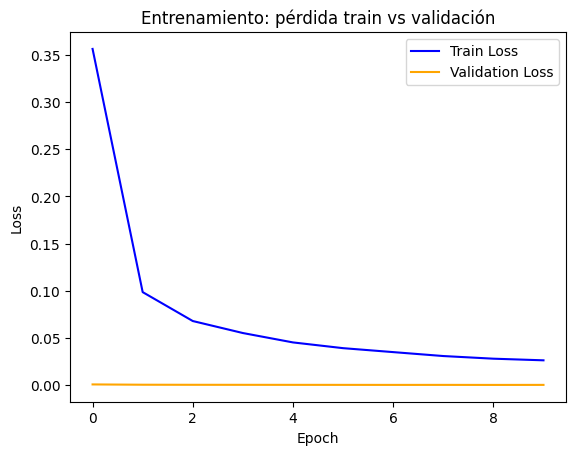

Accuracy adversario: 0.9913


In [ ]:
# Creamos una nuva red y la entrenamos con los ejemplos adversarios
red_adversaria = NN(28*28)
red_adversaria.train_(X_adversarial_train, y_adversarial_train, X_adversarial_test, y_adversarial_test, epochs= 10)
print(f'Accuracy adversario: {red_adversaria.accuracy(X_adversarial_test, y_adversarial_test)}')

## Apartado VII

### Ahora vamos a atacar las imágenes adversarias para obtener imágenes doblemente adversarias.

In [ ]:
# Generamos las imágenes adversarias para entrenamiento y test
train_dataset_loader_adversarial = DataLoader(TensorDataset(X_adversarial_train, y_adversarial_train), batch_size= 2048)
modified_images_train_2, labels_train_2 = get_adversarial_images(red_adversaria, train_dataset_loader, epsilon= 0.2, device= 'cpu')
test_dataset_loader_adversarial = DataLoader(TensorDataset(X_adversarial_test, y_adversarial_test), batch_size= 2048)
modified_images_test_2, labels_test_2 = get_adversarial_images(red_adversaria, test_dataset_loader, epsilon= 0.2, device= 'cpu')

# Equivalente a poner require_grad False
modified_images_train_2 = modified_images_train.detach()
modified_images_test_2 = modified_images_test.detach()

X_adversarial_train_2 = torch.cat([X_adversarial_train, modified_images_train_2], dim= 0)
y_adversarial_train_2 = torch.cat([y_adversarial_train, labels_train_2], dim= 0)
X_adversarial_test_2 = torch.cat([X_adversarial_test, modified_images_test_2], dim= 0)
y_adversarial_test_2 = torch.cat([y_adversarial_test, labels_test_2], dim= 0)

In [ ]:
# Vemos el accuracy solamente para las imágenes doblemente adversarias
print(f'Accuracy doblemente adversario: {red_adversaria.accuracy(X_adversarial_test_2, y_adversarial_test_2, device='cpu')}')

c:\Users\Usuario\Desktop\Programacion\Python\pyver\py3127\Lib\site-packages\torch\utils\data\dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Accuracy doblemente adversario: 0.9941


### Aparentemente el accuracy sigue siendo muy bueno con las imágenes doblemente adversarias, pero vamos finalmente a entreanr con todo el conjunto de imagenes (originales, adversarias y doblemente adversarias)

 10%|█         | 1/10 [00:16<02:29, 16.66s/it]

Epoch 1/10 | Train Loss: 0.2382 | Val Loss: 0.0005 | Accuracy: 98.77%


 20%|██        | 2/10 [00:33<02:13, 16.72s/it]

Epoch 2/10 | Train Loss: 0.0589 | Val Loss: 0.0003 | Accuracy: 99.11%


 30%|███       | 3/10 [00:50<01:57, 16.74s/it]

...

Epoch 8/10 | Train Loss: 0.0197 | Val Loss: 0.0002 | Accuracy: 99.39%


 90%|█████████ | 9/10 [02:32<00:16, 16.98s/it]

Epoch 9/10 | Train Loss: 0.0185 | Val Loss: 0.0002 | Accuracy: 99.33%


100%|██████████| 10/10 [02:49<00:00, 16.92s/it]

Epoch 10/10 | Train Loss: 0.0162 | Val Loss: 0.0002 | Accuracy: 99.42%


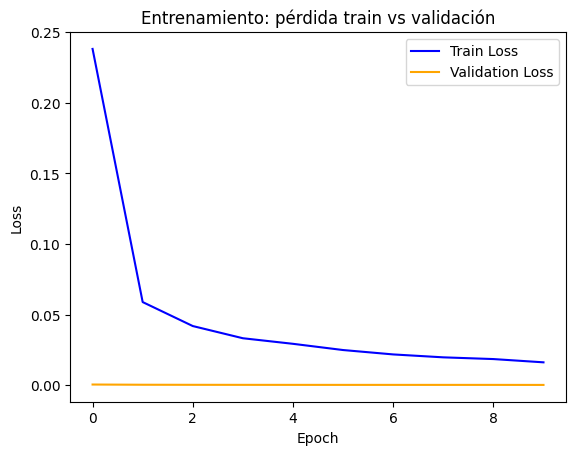

Accuracy doblemente adversario: 0.9942333333333333


In [ ]:
red_doblemente_adversaria = NN(28*28)
red_doblemente_adversaria.train_(X_adversarial_train_2, y_adversarial_train_2, X_adversarial_test_2, y_adversarial_test_2, epochs= 10)
print(f'Accuracy doblemente adversario: {red_doblemente_adversaria.accuracy(X_adversarial_test_2, y_adversarial_test_2)}')